<a href="https://colab.research.google.com/github/lindajia9/IDX-ds58/blob/main/01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [31]:
files = [
    "CRMLSSold202511.csv",
    "CRMLSSold202512.csv",
    "CRMLSSold202602.csv",
    "CRMLSSold202603.csv",
    "CRMLSSold202604.csv",
    "CRMLSSold202605.csv"
]

dfs = [pd.read_csv(file) for file in files]

df = pd.concat(dfs, ignore_index=True)

In [32]:
df.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,OrangeCounty,OrangeCounty,"Carpet,Tile",False,NaN,NaN,False,1250000.0,1147233684,mattkanoudi@gmail.com,...,NaN,5913.0,3.0,False,2.0,Huntington Beach Union High,92646,0.0,5913.0,NaN
1,Mlslistings,Mlslistings,Carpet,False,NaN,NaN,NaN,NaN,1147228247,babeksells@gmail.com,...,NaN,18432.0,NaN,False,2.0,Other,95124,NaN,18432.0,NaN
2,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,799900.0,1147223143,rigosd@gmail.com,...,NaN,5300.0,0.0,NaN,2.0,San Diego Unified,92173,0.0,5300.0,NaN
3,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,925000.0,1147209231,conchita@conchitalopez.com,...,NaN,5272.0,1.0,NaN,3.0,Sweetwater Union,92154,55.0,5272.0,NaN
4,NorthSanLuisObispo,NorthSanLuisObispo,NaN,False,NaN,NaN,False,1300000.0,1147200364,dmvonderheide@gmail.com,...,NaN,10500.0,3.0,False,3.0,Templeton Unified,93465,0.0,10500.0,NaN


In [33]:
df = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
]

In [34]:
print(df["ClosePrice"].describe())
print(df["LivingArea"].describe())
print(df["BedroomsTotal"].describe())
print(df["BathroomsTotalInteger"].describe())
print(df["LotSizeArea"].describe())

count    6.397600e+04
mean     1.346895e+06
std      7.566865e+06
min      6.850000e+02
25%      6.250000e+05
50%      8.950000e+05
75%      1.430000e+06
max      7.960000e+08
Name: ClosePrice, dtype: float64
count    63951.000000
mean      2052.535838
std       1035.518085
min          0.000000
25%       1387.000000
50%       1824.000000
75%       2450.000000
max      31068.000000
Name: LivingArea, dtype: float64
count    63976.000000
mean         3.495514
std          0.964770
min          0.000000
25%          3.000000
50%          3.000000
75%          4.000000
max         19.000000
Name: BedroomsTotal, dtype: float64
count    63975.000000
mean         2.639969
std          1.129875
min          0.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         23.000000
Name: BathroomsTotalInteger, dtype: float64
count    6.290200e+04
mean     1.859146e+04
std      1.819380e+05
min      0.000000e+00
25%      5.370250e+03
50%      7.010000e+03
75%      9.886750e

### EDA Plots

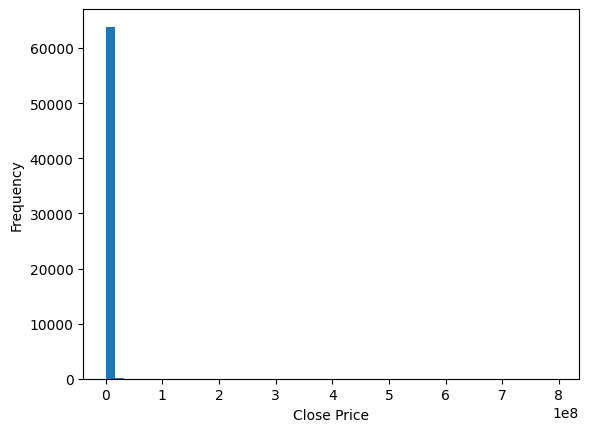

In [35]:
plt.hist(df["ClosePrice"], bins=50)
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

The vast majority of properties have lower closing prices (more affordable), concentrating heavily towards the left side of the plot.

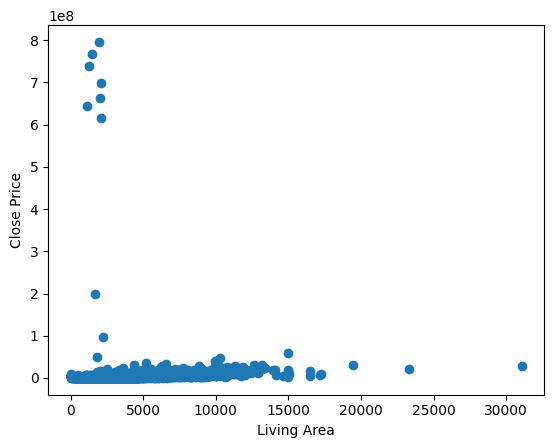

In [36]:
plt.scatter(df["LivingArea"], df["ClosePrice"])
plt.xlabel("Living Area")
plt.ylabel("Close Price")
plt.show()


*   For the majority of data points, there appears to be a positive correlation.
*   Most of the data points are concentrated in the bottom-left corner of the plot. This indicates that a large number of properties have relatively smaller living areas and lower closing prices.


*   Outliers: There are properties with very large 'ClosePrice' values that don't necessarily correspond to exceptionally large 'LivingArea' values; also properties with very large 'LivingArea' but not commensurately high 'ClosePrice'






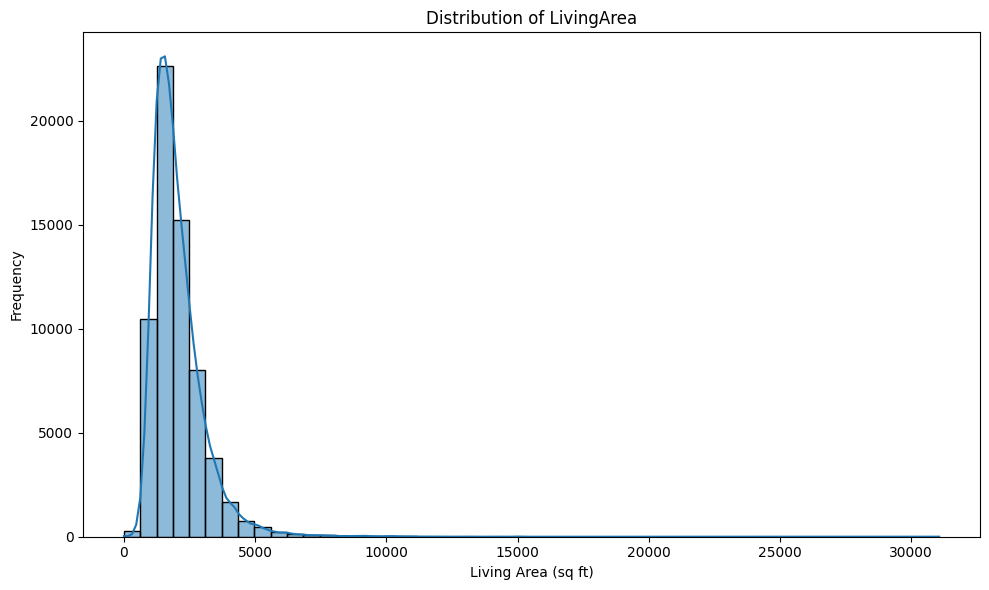

In [37]:

# Histogram for LivingArea
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['LivingArea'].dropna(), bins=50, kde=True, ax=ax)
ax.set_title('Distribution of LivingArea')
ax.set_xlabel('Living Area (sq ft)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()




*   right-skewed distribution: most properties have a smaller living area & fewer properties have very large living areas
*   peak of the distribution is around 1500-2000 sq ft (most common living area range)


*   outliers may be present toward the end of the tail (properties with unusually large living areas)





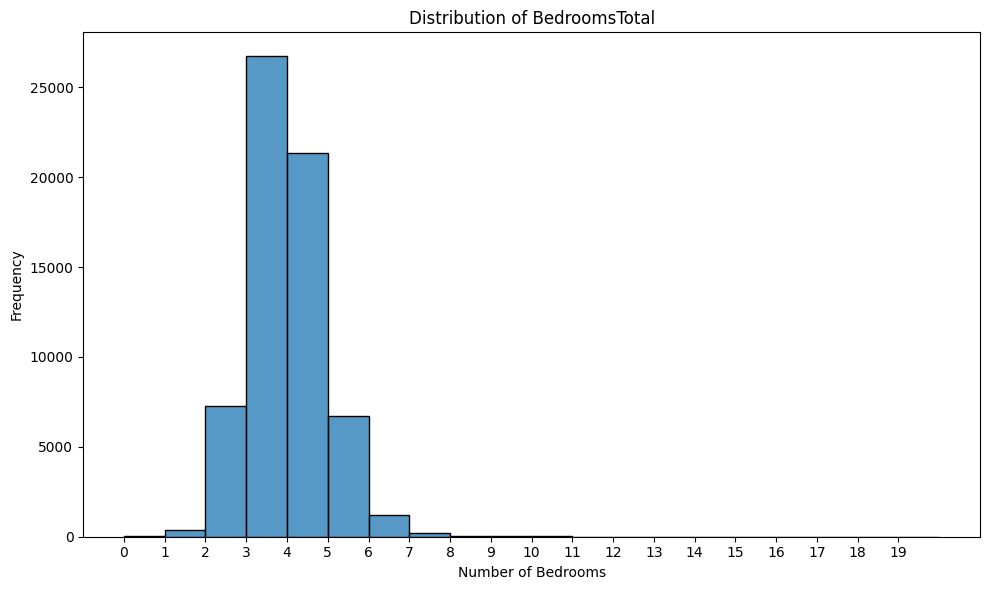

In [38]:
# Histogram for BedroomsTotal
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['BedroomsTotal'].dropna(), bins=range(int(df['BedroomsTotal'].min()), int(df['BedroomsTotal'].max()) + 2), kde=False, ax=ax)
ax.set_title('Distribution of BedroomsTotal')
ax.set_xlabel('Number of Bedrooms')
ax.set_ylabel('Frequency')
plt.xticks(range(int(df['BedroomsTotal'].min()), int(df['BedroomsTotal'].max()) + 1))
plt.tight_layout()
plt.show()




*   distribution is roughly bell-shaped
*   most common number of bedrooms is 3


*   a few properties have 0 or up to 19 bedrooms
*   very few properties have 7 or more bedrooms





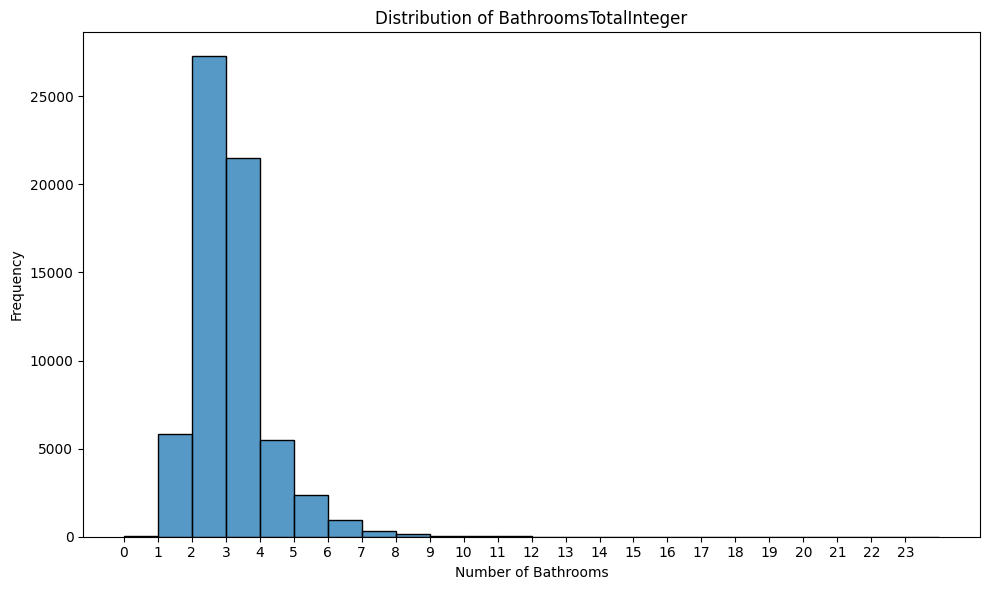

In [39]:
# Histogram for BathroomsTotalInteger
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['BathroomsTotalInteger'].dropna(), bins=range(int(df['BathroomsTotalInteger'].min()), int(df['BathroomsTotalInteger'].max()) + 2), kde=False, ax=ax)
ax.set_title('Distribution of BathroomsTotalInteger')
ax.set_xlabel('Number of Bathrooms')
ax.set_ylabel('Frequency')
plt.xticks(range(int(df['BathroomsTotalInteger'].min()), int(df['BathroomsTotalInteger'].max()) + 1))
plt.tight_layout()
plt.show()




*   roughly bell-shaped; maybe also a bit right-skewed
*   most common number of bathrooms is 2


*   minimum number of bathrooms is 0; max number of bathrooms is 23 (outliers)





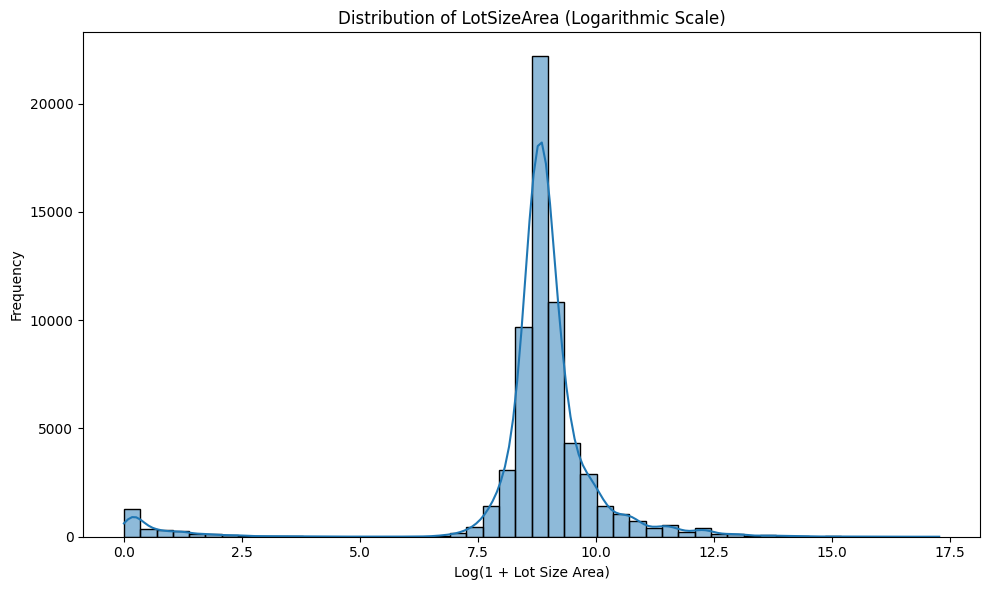

In [40]:
# Histogram for LotSizeArea with logarithmic scale (to help visualize wide ranges)
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(np.log1p(df['LotSizeArea'].dropna()), bins=50, kde=True, ax=ax)
ax.set_title('Distribution of LotSizeArea (Logarithmic Scale)')
ax.set_xlabel('Log(1 + Lot Size Area)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()




*   the log-transformed data looks normal distributed and bell-shaped overall
*   proportional differences are more evenly distributed


*   the smaller peak in the left tail may indicate a distinct cluster of properties with significantly smaller lot sizes





To get a clearer view of `ClosePrice` distribution, especially given its extreme skewness, let's visualize it on a logarithmic scale. This will compress the larger values and expand the smaller values, making the spread more visible.

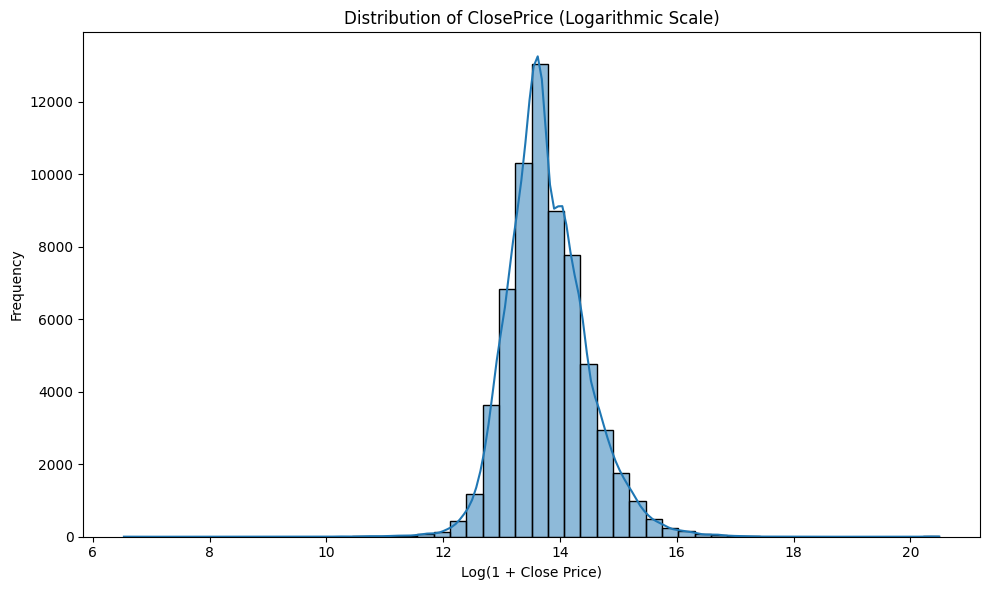

In [41]:
# Histogram for ClosePrice with logarithmic scale
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(np.log1p(df['ClosePrice'].dropna()), bins=50, kde=True, ax=ax)
ax.set_title('Distribution of ClosePrice (Logarithmic Scale)')
ax.set_xlabel('Log(1 + Close Price)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()




*   looks more normally distributed than the previous histogram of close price which was extremely right-skewed


*   plot suggests that there are only a few extremely expensive properties





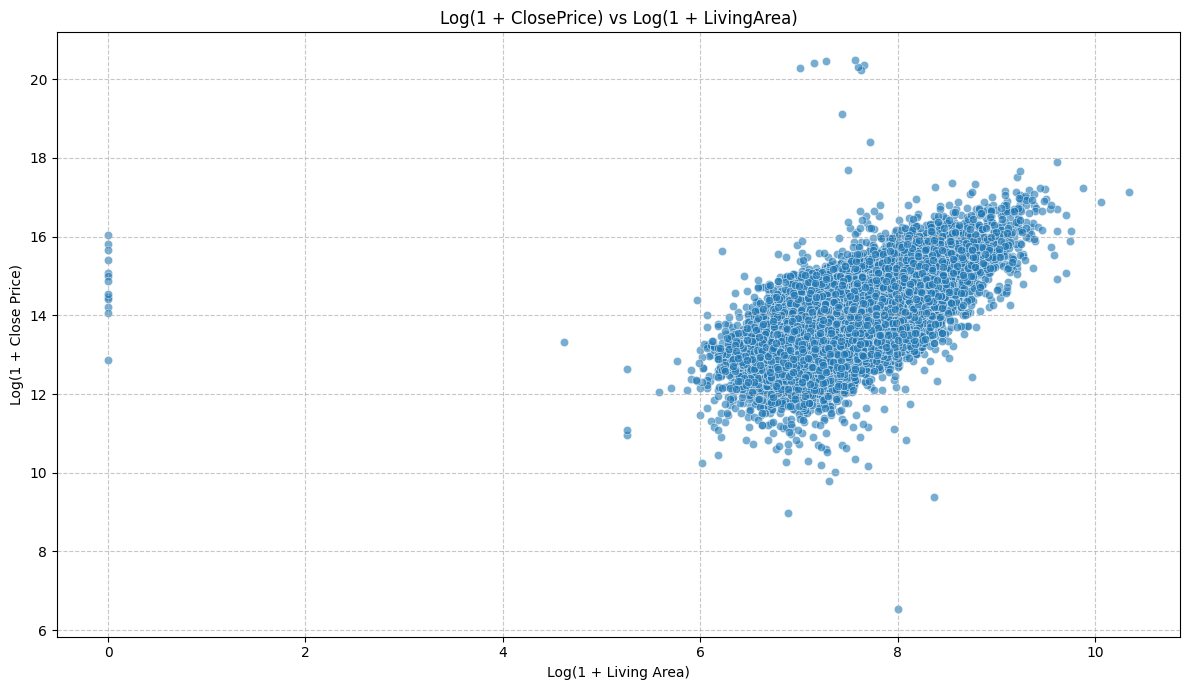

In [42]:
# Scatter plot of Log(1 + LivingArea) vs Log(1 + ClosePrice)
# the relationship after handling skewness
fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(x=np.log1p(df['LivingArea'].dropna()), y=np.log1p(df['ClosePrice'].dropna()), ax=ax, alpha=0.6)
ax.set_title('Log(1 + ClosePrice) vs Log(1 + LivingArea)')
ax.set_xlabel('Log(1 + Living Area)')
ax.set_ylabel('Log(1 + Close Price)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



*   positive correlations between the log-transformed living area and close price
*   dense cluster of points: many properties fall within a common range of living areas and correponding prices


*   can see a few outliers (other factors may contribute)
*   seems overall like a linear-like relationship





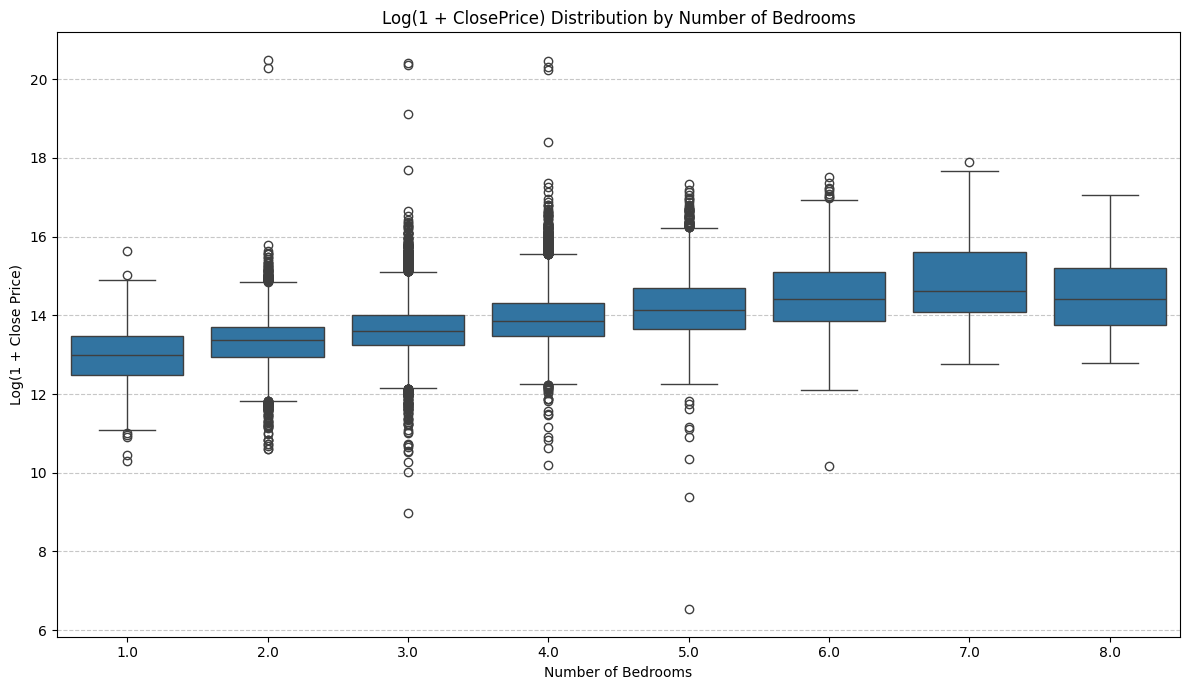

In [43]:
# Box plot of Log(1 + ClosePrice) by BedroomsTotal
# Filter bedrooms to a reasonable range for better visualization
df_filtered_bedrooms = df[df['BedroomsTotal'].between(1, 8)]

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(x='BedroomsTotal', y=np.log1p(df_filtered_bedrooms['ClosePrice'].dropna()), data=df_filtered_bedrooms, ax=ax)
ax.set_title('Log(1 + ClosePrice) Distribution by Number of Bedrooms')
ax.set_xlabel('Number of Bedrooms')
ax.set_ylabel('Log(1 + Close Price)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



*   the median tends to increase as the number of bedrooms increases from 1 to 7, suggesting that properties with more bedrooms tend to have higher prices
*   more variability in the close prices for properties with more bedrooms


*   many outliers for properties with 2 to 5 bedrooms





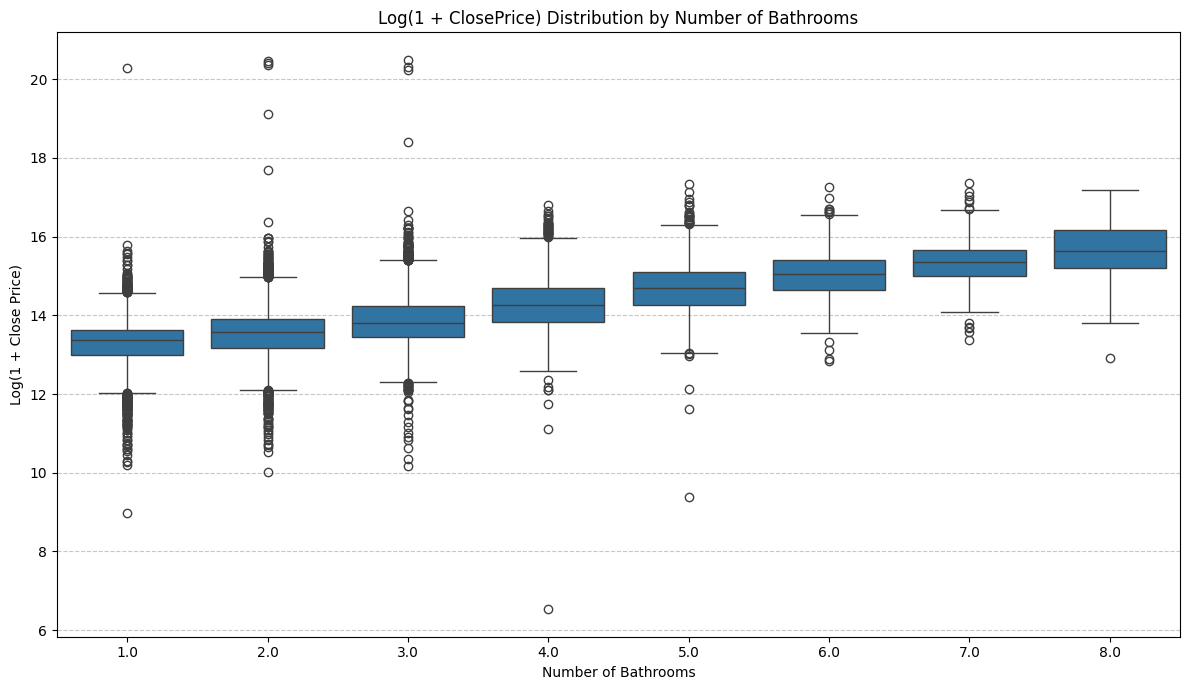

In [44]:
# Box plot of Log(1 + ClosePrice) by BathroomsTotalInteger
# Filter bathrooms to a reasonable range for better visualization
df_filtered_bathrooms = df[df['BathroomsTotalInteger'].between(1, 8)]

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(x='BathroomsTotalInteger', y=np.log1p(df_filtered_bathrooms['ClosePrice'].dropna()), data=df_filtered_bathrooms, ax=ax)
ax.set_title('Log(1 + ClosePrice) Distribution by Number of Bathrooms')
ax.set_xlabel('Number of Bathrooms')
ax.set_ylabel('Log(1 + Close Price)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



*   positive overall trend
*   outliers are present

